# 13 — Execution, Capacity & Margin

**Chain position:** … → Construction → Risk → Factor Risk → `Execution`

Notebook 10 proved the book can be **expressed** in whole lots. This one asks the two questions
that stand between an expressible book and a real one:

> **What does it cost to trade, and can the account carry it?**

### Why the flat 25bps had to go

`config.COST_BPS = 25` was a reasonable placeholder and a poor institutional answer, because the
two legs are **different instruments with different statutory charges**:

| | long leg | short leg |
|---|---|---|
| instrument | cash delivery | stock futures |
| STT | 0.10%, **both** sides | 0.05%, **sell only** (0.02% before Budget 2026) |
| stamp duty | 0.015% on buy | 0.002% on buy |
| exchange charge | 0.00297% | 0.00173% |

A single blended number cannot express that, and the asymmetry is large — the short leg's
explicit cost is roughly a **third** of the long leg's. That changes where turnover is worth
spending, and it is invisible in one figure.

The second thing a flat number cannot express is that **cost is not linear in size**. Impact
grows with the square root of participation, so a book that doubles its capital more than doubles
its cost. Without that term there is no capacity question — and capacity is the first thing an
allocator asks about.

### Why margin belongs here

The README named SPAN+ELM as one of the three constraints making trap #5 real, and then never
computed it. A short leg that quantises perfectly into whole lots is still undeployable if those
lots demand most of the capital as margin — and margin **rises with volatility**, so the day the
market moves is the day the requirement grows, on positions that have simultaneously moved against
you.

SPAN cannot be reproduced from public data; it comes from a proprietary daily risk array. What is
computed here is a documented approximation with the right shape, labelled as one everywhere it
surfaces — and it should be read as a **floor**: broker-quoted initial margin on single-stock
futures commonly runs well above it.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, fetch, align, dashboard, costs, margin, risk as rk,
                 portfolio as pf, indicators as ind, viz)

REFRESH = False
mkt.bootstrap(refresh=REFRESH)

book_path = config.OUTPUT_DIR / "portfolio_book.csv"
if not book_path.exists():
    raise FileNotFoundError(f"{book_path} not found -- run notebook 10 first")

raw = pd.read_csv(book_path).set_index("ticker")
book = pd.DataFrame({"side": raw["side"], "weight": raw["realised_weight"]})
lots = pd.to_numeric(raw["lot"], errors="coerce")
units = pd.to_numeric(raw.get("units", pd.Series(dtype=float)), errors="coerce")
CAPITAL = config.DEFAULT_CAPITAL

frames, failures = fetch.price_histories(list(book.index), period="1y")
if failures:
    display(pd.DataFrame(failures, columns=["ticker", "reason"]))
panel = align.align_to_calendar(fetch.close_frame(frames), calendar="NSE")
rets = align.to_returns(panel).dropna(how="all")

# Both helpers live in `indicators` so every notebook computes them the same way.
# The naive one-liner for ADV is wrong twice: a partially-printed current session
# gives NaN, and mean-price x mean-volume is not the mean of the product.
adv = ind.adv_value(frames, window=20)
dvol = ind.daily_vol(rets, window=63)
px_last = align.latest_row(panel)

print(f"book {len(book)} names | gross {book['weight'].abs().sum():.3f} | "
      f"capital {CAPITAL:,.0f}")
print(f"prices as of {px_last.attrs['as_of'].date()} "
      f"({px_last.attrs['coverage_%']:.0f}% coverage)")
print(f"ADV median INR {adv.median()/1e7:,.0f} cr | median daily vol "
      f"{dvol.median()*100:.2f}%")

mkt v2.0.0 | run 2026-09-11 12:49 | REFRESH=False | cache=G:\stock market analysis\.claude\worktrees\code-review-quotes-3844ce\data\cache


  fetched 11/11 tickers in 4s
book 11 names | gross 0.815 | capital 10,000,000
prices as of 2026-09-11 (100% coverage)
ADV median INR 242 cr | median daily vol 1.36%


## 1. The statutory table

Printed once so nobody has to read the code to learn why the short leg's entry is cheap and its
exit is not.

Note where GST applies: brokerage, the exchange transaction charge and the SEBI fee — **not** STT
or stamp duty, which are themselves taxes. Getting that subset wrong is the most common error in
a hand-rolled India cost model, and it is worth about 3.5bps on the long leg.

In [2]:
cm = costs.cost_matrix()
display(cm.round(4))
print(f"rates as of {cm.attrs['as_of']} — re-check against the current SEBI and exchange "
      f"circulars before trading; brokerage is the only negotiable line.")

long_rt = costs.round_trip_bps(costs.CASH, is_short=False)
short_rt = costs.round_trip_bps(costs.FUT, is_short=True)
print()
print(f"explicit round trip — long (cash delivery) {long_rt:6.2f} bps")
print(f"explicit round trip — short (stock future) {short_rt:6.2f} bps  "
      f"({long_rt/short_rt:.1f}x cheaper)")
print(f"config.COST_BPS placeholder                {config.COST_BPS:6.2f} bps flat, both legs")
print()
print(f"blended 50/50, derived rather than assumed: "
      f"{costs.blended_round_trip_bps(0.5):.2f} bps")

brokerage   stt  exchange_txn  sebi_fee  stamp_duty  gst  total
instrument    side                                                                 
cash_delivery buy        3.00 10.00          0.30      0.01        1.50 0.60  15.40
              sell       3.00 10.00          0.30      0.01        0.00 0.60  13.90
stock_futures buy        2.00  0.00          0.17      0.01        0.20 0.39   2.78
              sell       2.00  5.00          0.17      0.01        0.00 0.39   7.58

rates as of 2026-09-11 — re-check against the current SEBI and exchange circulars before trading; brokerage is the only negotiable line.

explicit round trip — long (cash delivery)  29.30 bps
explicit round trip — short (stock future)  10.35 bps  (2.8x cheaper)
config.COST_BPS placeholder                 25.00 bps flat, both legs

blended 50/50, derived rather than assumed: 19.83 bps


## 2. What this book costs to put on and take off

Explicit charges plus impact, per name. Impact is the square-root law,
`c · σ_daily · √(value / ADV)`, plus a half-spread — the standard Almgren/Kissell form with one
free parameter.

`extrapolating` flags any position above the participation rate the model was calibrated on. The
model does not silently keep scaling past its own range.

In [3]:
tc = costs.trade_cost(book, capital=CAPITAL, adv_value=adv, daily_vol=dvol)
display(tc[["side", "instrument", "value", "explicit_in_bps", "explicit_out_bps",
            "impact_in_bps", "total_bps", "total_INR", "participation",
            "extrapolating"]].round(4))

display(costs.assert_cost_sanity(tc, label="model book"))
print(f"weighted average {tc.attrs['weighted_avg_bps']:.1f} bps round trip = "
      f"INR {tc.attrs['total_INR']:,.0f} on a {CAPITAL:,.0f} book")
print(f"as a share of capital: {tc.attrs['total_bps_of_capital']:.1f} bps")

,side,instrument,value,explicit_in_bps,explicit_out_bps,impact_in_bps,total_bps,total_INR,participation,extrapolating
ticker,,,,,,,,,,
KOTAKBANK.NS,long,cash_delivery,"625,240.00",15.40,13.90,3.22,35.75,"2,234.95",0.00,False
COALINDIA.NS,long,cash_delivery,"686,110.00",15.40,13.90,3.09,35.48,"2,434.18",0.00,False
ADANIPORTS.NS,long,cash_delivery,"438,260.00",15.40,13.90,3.34,35.97,"1,576.63",0.00,False
ICICIBANK.NS,long,cash_delivery,"748,150.00",15.40,13.90,2.63,34.56,"2,585.74",0.00,False
JSWSTEEL.NS,long,cash_delivery,"540,940.00",15.40,13.90,3.52,36.34,"1,965.89",0.00,False
TITAN.NS,long,cash_delivery,"633,670.00",15.40,13.90,3.30,35.91,"2,275.22",0.00,False
TMPV.NS,short,stock_futures,"484,160.00",7.58,2.78,3.46,17.28,836.48,0.00,False
DRREDDY.NS,short,stock_futures,"736,310.00",7.58,2.78,4.22,18.79,"1,383.40",0.00,False
HINDUNILVR.NS,short,stock_futures,"1,161,780.00",7.58,2.78,4.14,18.63,"2,163.97",0.00,False


,names,weighted_avg_bps,total_INR,n_extrapolating,result
0,11,26.47,"21,573.00",0,cost model internally consistent


weighted average 26.5 bps round trip = INR 21,573 on a 10,000,000 book
as a share of capital: 21.6 bps


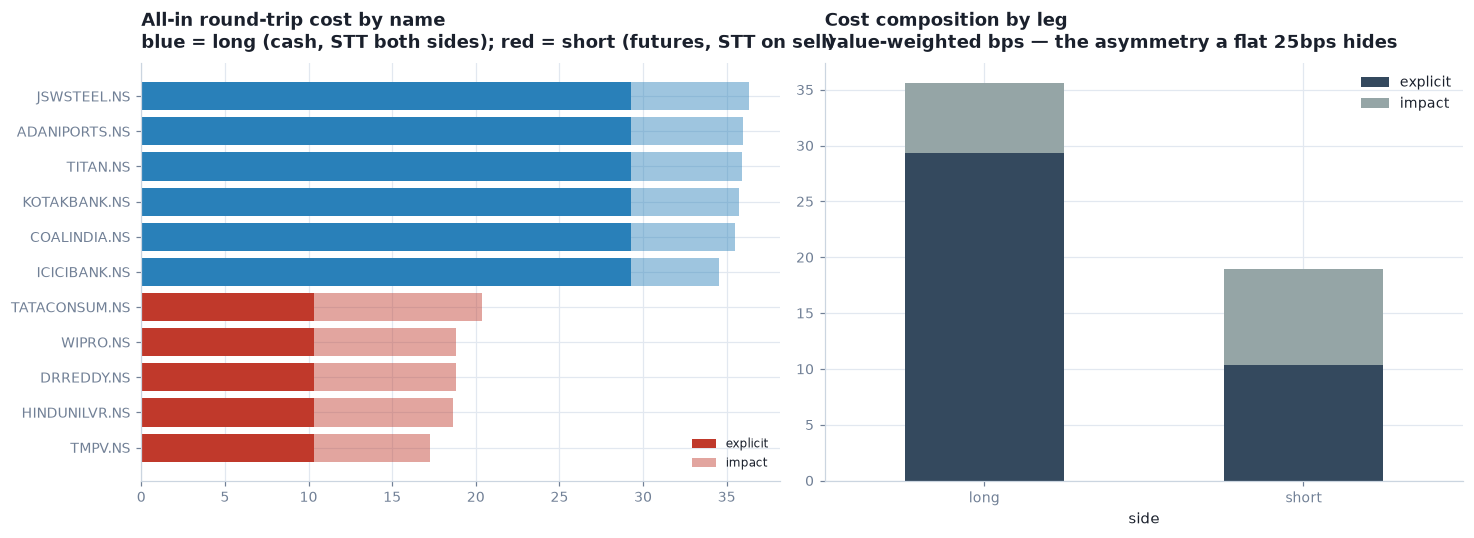

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

d = tc.sort_values("total_bps")
colors = ["#c0392b" if s == "short" else "#2980b9" for s in d["side"]]
axes[0].barh(d.index, d["explicit_in_bps"] + d["explicit_out_bps"],
             color=colors, label="explicit")
axes[0].barh(d.index, d["impact_in_bps"] + d["impact_out_bps"],
             left=d["explicit_in_bps"] + d["explicit_out_bps"],
             color=colors, alpha=0.45, label="impact")
axes[0].legend(fontsize=8)
viz.title(axes[0], "All-in round-trip cost by name",
          "blue = long (cash, STT both sides); red = short (futures, STT on sell)")

by_leg = tc.groupby("side").apply(
    lambda g: pd.Series({
        "explicit": float(((g["explicit_in_bps"] + g["explicit_out_bps"]) * g["value"]).sum()
                          / g["value"].sum()),
        "impact": float(((g["impact_in_bps"].fillna(0) + g["impact_out_bps"].fillna(0))
                         * g["value"]).sum() / g["value"].sum()),
    }), include_groups=False)
by_leg.plot(kind="bar", stacked=True, ax=axes[1],
            color=["#34495e", "#95a5a6"], rot=0)
viz.title(axes[1], "Cost composition by leg",
          "value-weighted bps — the asymmetry a flat 25bps hides")
plt.tight_layout()
viz.save(fig, "13_cost_breakdown")
plt.show()

## 3. Capacity

The allocator's question, and it has an answer only because impact is concave: explicit cost is
linear in size and vanishes as a *share*, while impact grows as the square root of participation
and eventually eats everything.

`breakeven_alpha_bps` is the honest column. Notebook 07's verdict on the technical leg was **not
proven**, so this project has no credible alpha estimate to plug in. The question worth asking is
inverted: *how much gross alpha would this book need, at each size, simply to cover its own
costs?*

In [5]:
cap = costs.capacity_curve(book, adv, dvol,
                           capitals=[1e6, 2.5e6, 5e6, 1e7, 2.5e7, 5e7, 1e8,
                                     2.5e8, 5e8, 1e9, 2.5e9],
                           gross_alpha_bps_ann=300.0,
                           turnovers_per_year=12.0)
display(cap.round(2))
print(f"assumed gross alpha {cap.attrs['gross_alpha_bps_ann']:.0f} bps/yr at "
      f"{cap.attrs['turnovers_per_year']:.0f} turnovers/yr")
c = cap.attrs["capacity_INR"]
print(f"capacity at that alpha: {'INR %.1f cr' % (c/1e7) if np.isfinite(c) else 'none of the tested sizes clears its own costs'}")

,round_trip_bps,ann_cost_bps,ann_cost_%,net_alpha_bps,breakeven_alpha_bps,max_participation,n_extrapolating
capital,,,,,,,
"1,000,000.00",23.65,283.75,2.84,16.25,283.75,0.00,0
"2,500,000.00",24.40,292.84,2.93,7.16,292.84,0.00,0
"5,000,000.00",25.26,303.09,3.03,-3.09,303.09,0.00,0
"10,000,000.00",26.47,317.59,3.18,-17.59,317.59,0.00,0
"25,000,000.00",28.86,346.35,3.46,-46.35,346.35,0.00,0
"50,000,000.00",31.56,378.77,3.79,-78.77,378.77,0.01,0
"100,000,000.00",35.38,424.62,4.25,-124.62,424.62,0.01,0
"250,000,000.00",42.96,515.58,5.16,-215.58,515.58,0.03,0
"500,000,000.00",51.51,618.09,6.18,-318.09,618.09,0.05,0


assumed gross alpha 300 bps/yr at 12 turnovers/yr
capacity at that alpha: INR 0.2 cr


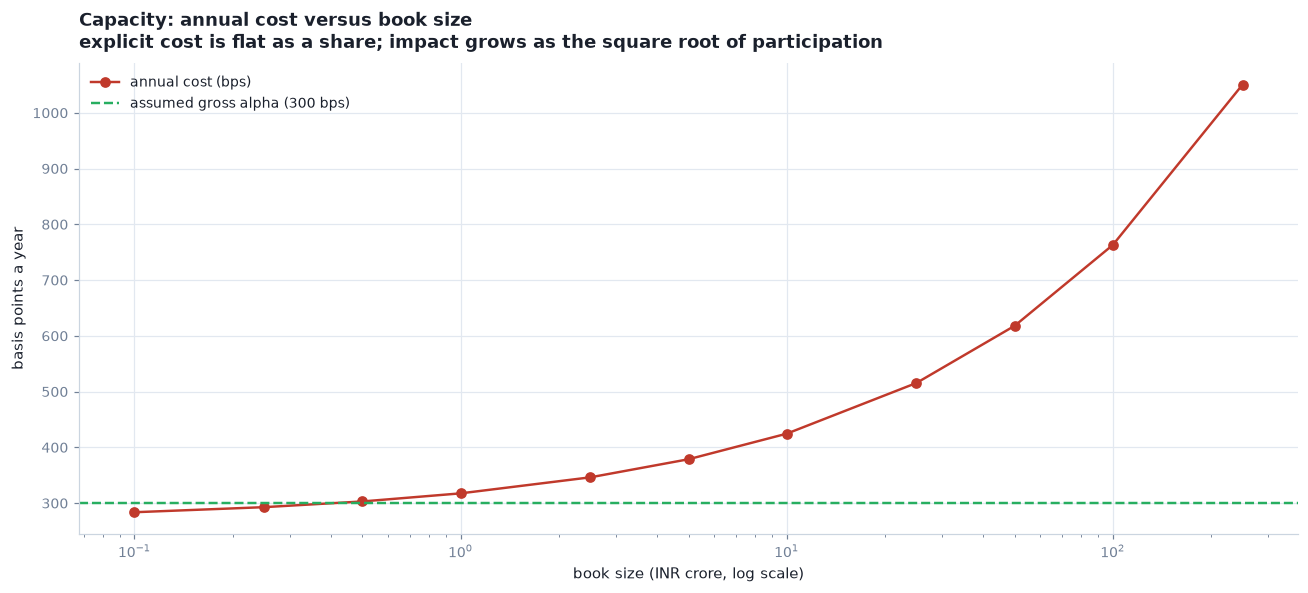

In [6]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(cap.index / 1e7, cap["ann_cost_bps"], marker="o", color="#c0392b",
        label="annual cost (bps)")
ax.axhline(cap.attrs["gross_alpha_bps_ann"], color="#27ae60", ls="--",
           label=f"assumed gross alpha ({cap.attrs['gross_alpha_bps_ann']:.0f} bps)")
ax.set_xscale("log")
ax.set_xlabel("book size (INR crore, log scale)")
ax.set_ylabel("basis points a year")
ax.legend(fontsize=9)
viz.title(ax, "Capacity: annual cost versus book size",
          "explicit cost is flat as a share; impact grows as the square root of participation")
plt.tight_layout()
viz.save(fig, "13_capacity_curve")
plt.show()

## 4. Liquidity

Position size against traded value, and the horizon a real exit would take.

One-day VaR silently assumes the book can be liquidated in one day. For a position that is a
large share of a day's volume at a tradeable participation rate, the real exit horizon is several
days and the risk over that horizon is roughly √days larger. That is the number that belongs in a
risk limit.

In [7]:
liq = pf.liquidity_check(book, adv, capital=CAPITAL)
display(liq.round(4))
print(f"breaches of the {liq.attrs['max_pct_adv']:.0f}% ADV cap: {liq.attrs['n_breach']}")

cov = rk.shrunk_cov(rets.tail(config.COV_LOOKBACK_DAYS))
w = book["weight"].reindex(cov.index).fillna(0.0)
lav = rk.liquidity_adjusted_var(w, cov, adv, capital=CAPITAL, participation=0.20)
display(lav.round(4))
print(f"book VaR 1d {lav.attrs['book_var_1d_%']:.3f}% -> liquidity-adjusted "
      f"{lav.attrs['book_var_liq_%']:.3f}% at a p95 exit horizon of "
      f"{lav.attrs['p95_days_to_liquidate']:.2f} days "
      f"(worst name: {lav.attrs['worst_name']})")

,side,position_value,adv_value,pct_of_adv,days_to_trade,breach
ticker,,,,,,
KOTAKBANK.NS,long,"625,240.00","4,954,957,588.84",0.01,0.00,False
COALINDIA.NS,long,"686,110.00","4,544,599,447.42",0.02,0.00,False
ADANIPORTS.NS,long,"438,260.00","4,168,673,474.02",0.01,0.00,False
ICICIBANK.NS,long,"748,150.00","12,433,547,450.30",0.01,0.00,False
JSWSTEEL.NS,long,"540,940.00","2,136,827,734.08",0.03,0.00,False
TITAN.NS,long,"633,670.00","2,523,090,023.36",0.03,0.00,False
TMPV.NS,short,"484,160.00","2,359,929,080.33",0.02,0.00,False
DRREDDY.NS,short,"736,310.00","1,313,797,626.60",0.06,0.01,False
HINDUNILVR.NS,short,"1,161,780.00","2,422,873,609.94",0.05,0.00,False


breaches of the 10% ADV cap: 0


,weight,position_value,adv_value,days_to_liquidate,var_1d_%,var_liq_%,liquidity_add_on_%
KOTAKBANK.NS,0.06,"625,240.00","4,954,957,588.84",1.00,0.14,0.14,0.00
COALINDIA.NS,0.07,"686,110.00","4,544,599,447.42",1.00,0.16,0.16,0.00
ADANIPORTS.NS,0.04,"438,260.00","4,168,673,474.02",1.00,0.13,0.13,0.00
ICICIBANK.NS,0.07,"748,150.00","12,433,547,450.30",1.00,0.15,0.15,0.00
JSWSTEEL.NS,0.05,"540,940.00","2,136,827,734.08",1.00,0.13,0.13,0.00
TITAN.NS,0.06,"633,670.00","2,523,090,023.36",1.00,0.15,0.15,0.00
TMPV.NS,-0.05,"484,160.00","2,359,929,080.33",1.00,0.25,0.25,0.00
DRREDDY.NS,-0.07,"736,310.00","1,313,797,626.60",1.00,0.18,0.18,0.00
HINDUNILVR.NS,-0.12,"1,161,780.00","2,422,873,609.94",1.00,0.26,0.26,0.00
TATACONSUM.NS,-0.11,"1,094,170.00","1,086,716,664.80",1.00,0.26,0.26,0.00


book VaR 1d 0.606% -> liquidity-adjusted 0.606% at a p95 exit horizon of 1.00 days (worst name: KOTAKBANK.NS)


## 5. Margin — can the account carry it?

Four claims on the same rupees, and the book is deployable only if they fit:

1. **long leg** — paid in full, cash delivery;
2. **short-leg margin** — SPAN + ELM, blocked while the position is on;
3. **mark-to-market buffer** — futures settle daily in *cash*, so a short moving against the book
   generates a cash call the same evening whatever the long leg is doing;
4. **free cash** — what is left, which had better not be negative.

The SPAN figure is a scan-range approximation; ELM is exact by rule. Note where the **regulatory
floor** binds: a name below roughly 1.4% daily volatility scans below the 5% minimum, so the floor
sets its margin — which is why omitting the floor would understate margin on exactly the low-vol
names a conservative book holds most of.

In [8]:
mt = margin.book_margin(book, px_last, lots, dvol, capital=CAPITAL,
                        units=units if len(units) else None)
if len(mt):
    display(mt[["target_weight", "notional", "daily_vol_%", "span_pct", "elm_pct",
                "margin_pct", "margin_INR", "margin_%_of_capital"]].round(3))
    at_floor = mt[mt["span_pct"] <= config.SPAN_MIN_SCAN_PCT * 100 + 1e-9]
    print(f"notional basis: {mt.attrs['notional_basis']}")
    print(f"total margin INR {mt.attrs['total_margin']:,.0f} on short notional "
          f"INR {mt.attrs['total_notional']:,.0f}")
    print(f"{len(at_floor)} name(s) pinned at the {config.SPAN_MIN_SCAN_PCT:.0%} "
          f"regulatory floor: {list(at_floor.index)}")
else:
    print("no short leg -- cash equity carries no margin")

adq = margin.capital_adequacy(book, mt, capital=CAPITAL)
display(pd.DataFrame([adq]).T.rename(columns={0: "value"}))
display(margin.assert_capital_adequate(adq, label="model book"))

,target_weight,notional,daily_vol_%,span_pct,elm_pct,margin_pct,margin_INR,margin_%_of_capital
ticker,,,,,,,,
HINDUNILVR.NS,-0.12,"1,160,940.01",1.50,5.27,3.50,8.77,"101,802.51",1.02
TATACONSUM.NS,-0.11,"1,094,059.97",1.39,5.00,3.50,8.50,"92,995.10",0.93
WIPRO.NS,-0.10,"1,002,300.02",1.31,5.00,3.50,8.50,"85,195.50",0.85
DRREDDY.NS,-0.07,"735,312.50",1.44,5.02,3.50,8.52,"62,673.58",0.63
TMPV.NS,-0.05,"484,479.98",1.71,6.00,3.50,9.49,"45,999.23",0.46


notional basis: realised whole lots
total margin INR 388,666 on short notional INR 4,477,092
2 name(s) pinned at the 5% regulatory floor: ['TATACONSUM.NS', 'WIPRO.NS']


,value
capital,10000000
long_leg_cash,"3,672,370.00"
short_leg_notional,"4,477,092.49"
short_leg_margin,"388,665.93"
mtm_buffer,"111,961.53"
mtm_buffer_days,3
total_committed,"4,172,997.46"
free_cash,"5,827,002.54"
free_cash_%,58.27
margin_utilisation,0.04


,capital,long_leg_cash,short_leg_margin,mtm_buffer,free_cash_%,margin_utilisation,result
0,"10,000,000.00","3,672,370.00","388,666.00","111,962.00",58.27,0.04,capital adequate to carry the book (SPAN appro...


### Margin under a volatility spike

The scenario that ends books. Margin is not a fixed claim — it scales with the scan range, so a
book comfortable in calm conditions can be at its utilisation limit after a doubling of volatility
**without a single trade**, and the response demanded is forced selling into the move that caused
it.

The escalation is non-linear because of the floor: names already pinned at the regulatory minimum
absorb a small vol shock with no increase at all, and then all of them start scaling at once.

,margin_INR,margin_%_of_capital,utilisation,breaches_limit,n_at_floor,increase_vs_base_%
vol_multiple,,,,,,
1.00,"388,665.93",3.89,0.04,False,2,0.00
1.25,"439,502.69",4.39,0.04,False,0,13.08
1.50,"496,063.58",4.96,0.05,False,0,27.63
2.00,"609,185.36",6.09,0.06,False,0,56.74
2.50,"722,307.14",7.22,0.07,False,0,85.84
3.00,"835,428.92",8.35,0.08,False,0,114.95


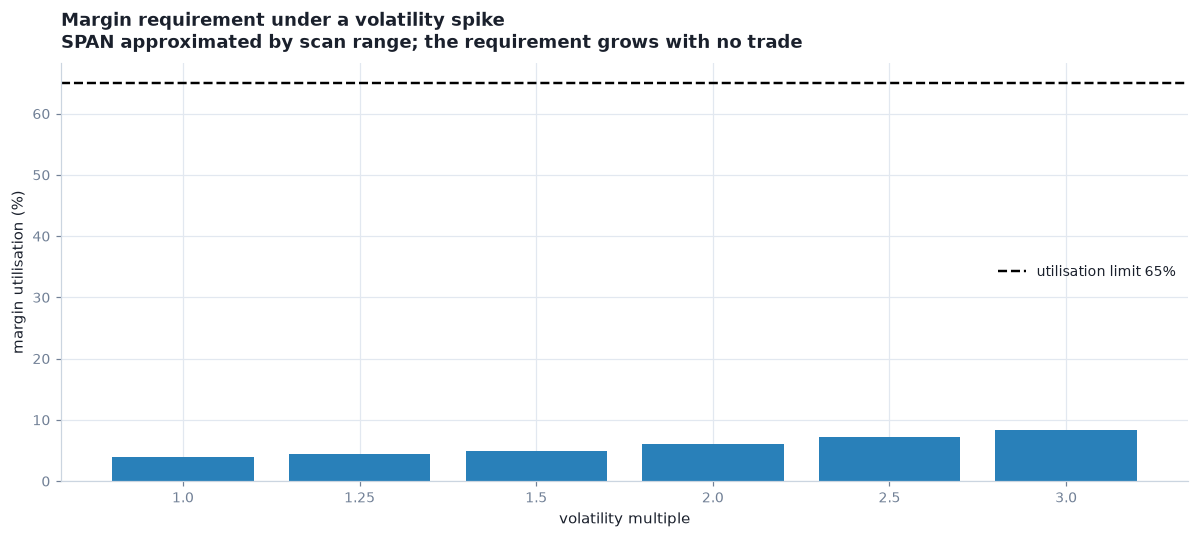

In [9]:
if len(mt):
    st = margin.margin_stress(mt, capital=CAPITAL,
                              vol_multiples=(1.0, 1.25, 1.5, 2.0, 2.5, 3.0))
    display(st.round(3))

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar([str(x) for x in st.index], st["utilisation"] * 100,
           color=["#c0392b" if b else "#2980b9" for b in st["breaches_limit"]])
    ax.axhline(config.MARGIN_UTILISATION_LIMIT * 100, color="black", ls="--",
               label=f"utilisation limit {config.MARGIN_UTILISATION_LIMIT:.0%}")
    ax.set_xlabel("volatility multiple")
    ax.set_ylabel("margin utilisation (%)")
    ax.legend(fontsize=9)
    viz.title(ax, "Margin requirement under a volatility spike",
              "SPAN approximated by scan range; the requirement grows with no trade")
    plt.tight_layout()
    viz.save(fig, "13_margin_stress")
    plt.show()
else:
    st = pd.DataFrame()

## 6. Signal

Published to `dashboard.json` as `13_execution_capacity`.

In [10]:
payload = {
    "signal": (f"{tc.attrs['weighted_avg_bps']:.0f} bps round trip | margin "
               f"utilisation {adq['margin_utilisation']:.1%}"),
    "score": round(float(tc.attrs["weighted_avg_bps"]), 1),
    "as_of": str(px_last.attrs["as_of"].date()),
    "capital": CAPITAL,
    "costs": {
        "weighted_avg_bps": float(tc.attrs["weighted_avg_bps"]),
        "total_INR": float(tc.attrs["total_INR"]),
        "long_explicit_round_trip_bps": long_rt,
        "short_explicit_round_trip_bps": short_rt,
        "flat_placeholder_bps": config.COST_BPS,
        "n_extrapolating": int(tc.attrs["n_extrapolating"]),
        "rates_as_of": config.COST_ASOF,
    },
    "capacity": {
        "gross_alpha_assumed_bps": float(cap.attrs["gross_alpha_bps_ann"]),
        "capacity_INR": (None if not np.isfinite(cap.attrs["capacity_INR"])
                         else float(cap.attrs["capacity_INR"])),
        "cost_at_1cr_bps": float(cap["ann_cost_bps"].reindex([1e7]).iloc[0])
        if 1e7 in cap.index else None,
        "cost_at_100cr_bps": float(cap["ann_cost_bps"].reindex([1e9]).iloc[0])
        if 1e9 in cap.index else None,
    },
    "liquidity": {
        "n_adv_breach": int(liq.attrs["n_breach"]),
        "p95_days_to_liquidate": float(lav.attrs["p95_days_to_liquidate"]),
        "var_1d_%": float(lav.attrs["book_var_1d_%"]),
        "var_liquidity_adjusted_%": float(lav.attrs["book_var_liq_%"]),
    },
    "margin": {
        "total_INR": float(mt.attrs["total_margin"]) if len(mt) else 0.0,
        "utilisation": float(adq["margin_utilisation"]),
        "free_cash_%": float(adq["free_cash_%"]),
        "adequate": bool(adq["adequate"]),
        "utilisation_at_2x_vol": (float(st.loc[2.0, "utilisation"])
                                  if len(st) and 2.0 in st.index else None),
        "basis": "SPAN approximated by scan range; ELM exact",
    },
}
dashboard.append("13_execution_capacity", payload)
display(dashboard.summary())

,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",80.75,2026-09-09,2026-09-09 05:19:06
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 05:23:04
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 05:20:28
8,09_positioning,"12 names scored, 6 short candidates checked fo...",60.19,2026-09-09,2026-09-09 05:20:53
9,10_portfolio,"6L / 5S, gross 0.82x, net -0.08x",5.54,2026-09-11,2026-09-11 07:18:23
